# Sleep Disorder Prediction - ANN
Using MLPClassifier with SMOTE and GridSearchCV on the Sleep Health and Lifestyle Dataset

## 1. Imports

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

## 2. Load Data

In [28]:
df = pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')

print('Shape:', df.shape)
print('\nMissing Values:')
print(df.isnull().sum())
print('\nTarget Distribution:')
print(df['Sleep Disorder'].value_counts(dropna=False))

df.head()

Shape: (374, 13)

Missing Values:
Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

Target Distribution:
Sleep Disorder
NaN            219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


## 3. Data Preprocessing

In [29]:
data = df.copy()

# Drop Person ID
data = data.drop('Person ID', axis=1)

# Treat missing Sleep Disorder as No Disorder
data['Sleep Disorder'] = data['Sleep Disorder'].fillna('No Disorder')

# Fix inconsistent BMI Category labels
data = data.replace('Normal Weight', 'Normal')

# Fix inconsistent and low-sample Occupation labels
data = data.replace('Software Engineer', 'Engineer')
occupation_map = {
    'Scientist': 'Other',
    'Manager': 'Other',
    'Sales Representative': 'Other'
}
data['Occupation'] = data['Occupation'].replace(occupation_map)

# Split Blood Pressure into Systolic and Diastolic
data[['Systolic BP', 'Diastolic BP']] = (
    data['Blood Pressure']
    .str.split('/', expand=True)
    .astype(int)
)
data = data.drop('Blood Pressure', axis=1)

# Remove duplicates
data = data.drop_duplicates()

print('Shape after preprocessing:', data.shape)
print('\nOccupation counts:')
print(data['Occupation'].value_counts())
print('\nBMI Category counts:')
print(data['BMI Category'].value_counts())

Shape after preprocessing: (132, 13)

Occupation counts:
Occupation
Nurse          29
Engineer       25
Doctor         24
Teacher        15
Lawyer         15
Accountant     11
Salesperson     9
Other           4
Name: count, dtype: int64

BMI Category counts:
BMI Category
Normal        73
Overweight    52
Obese          7
Name: count, dtype: int64


## 4. Encode Categorical Variables

In [30]:
# LabelEncoder for binary (Gender) and target (Sleep Disorder)
data['Gender'] = LabelEncoder().fit_transform(data['Gender'])

le_target = LabelEncoder()
data['Sleep Disorder'] = le_target.fit_transform(data['Sleep Disorder'])

# Store class names for later use in reports
target_names = le_target.classes_
print('Target classes:', target_names)

# One-hot encode multi-class categoricals
data = pd.get_dummies(data, columns=['Occupation', 'BMI Category'], dtype=int)

data.head()

Target classes: ['Insomnia' 'No Disorder' 'Sleep Apnea']


,Gender,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Sleep Disorder,Systolic BP,...,Occupation_Doctor,Occupation_Engineer,Occupation_Lawyer,Occupation_Nurse,Occupation_Other,Occupation_Salesperson,Occupation_Teacher,BMI Category_Normal,BMI Category_Obese,BMI Category_Overweight
0,1,27,6.1,6,42,6,77,4200,1,126,...,0,1,0,0,0,0,0,0,0,1
1,1,28,6.2,6,60,8,75,10000,1,125,...,1,0,0,0,0,0,0,1,0,0
3,1,28,5.9,4,30,8,85,3000,2,140,...,0,0,0,0,1,0,0,0,1,0
5,1,28,5.9,4,30,8,85,3000,0,140,...,0,1,0,0,0,0,0,0,1,0
6,1,29,6.3,6,40,7,82,3500,0,140,...,0,0,0,0,0,0,1,0,1,0


## 5. Define Features and Target

In [31]:
X = data.drop('Sleep Disorder', axis=1)
y = data['Sleep Disorder']

print('Features:', X.shape[1])
print('\nTarget distribution:')
print(y.value_counts())

Features: 21

Target distribution:
Sleep Disorder
1    73
2    30
0    29
Name: count, dtype: int64


## 6. Exploratory Data Analysis (EDA)

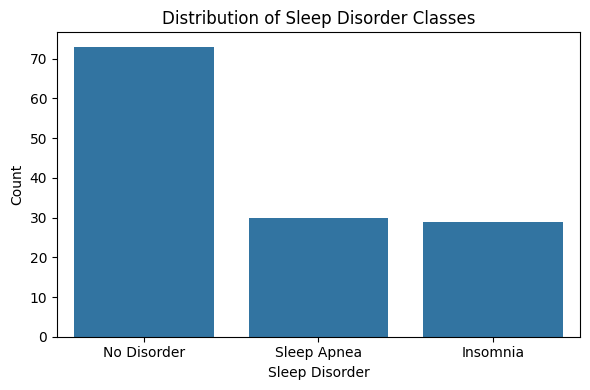

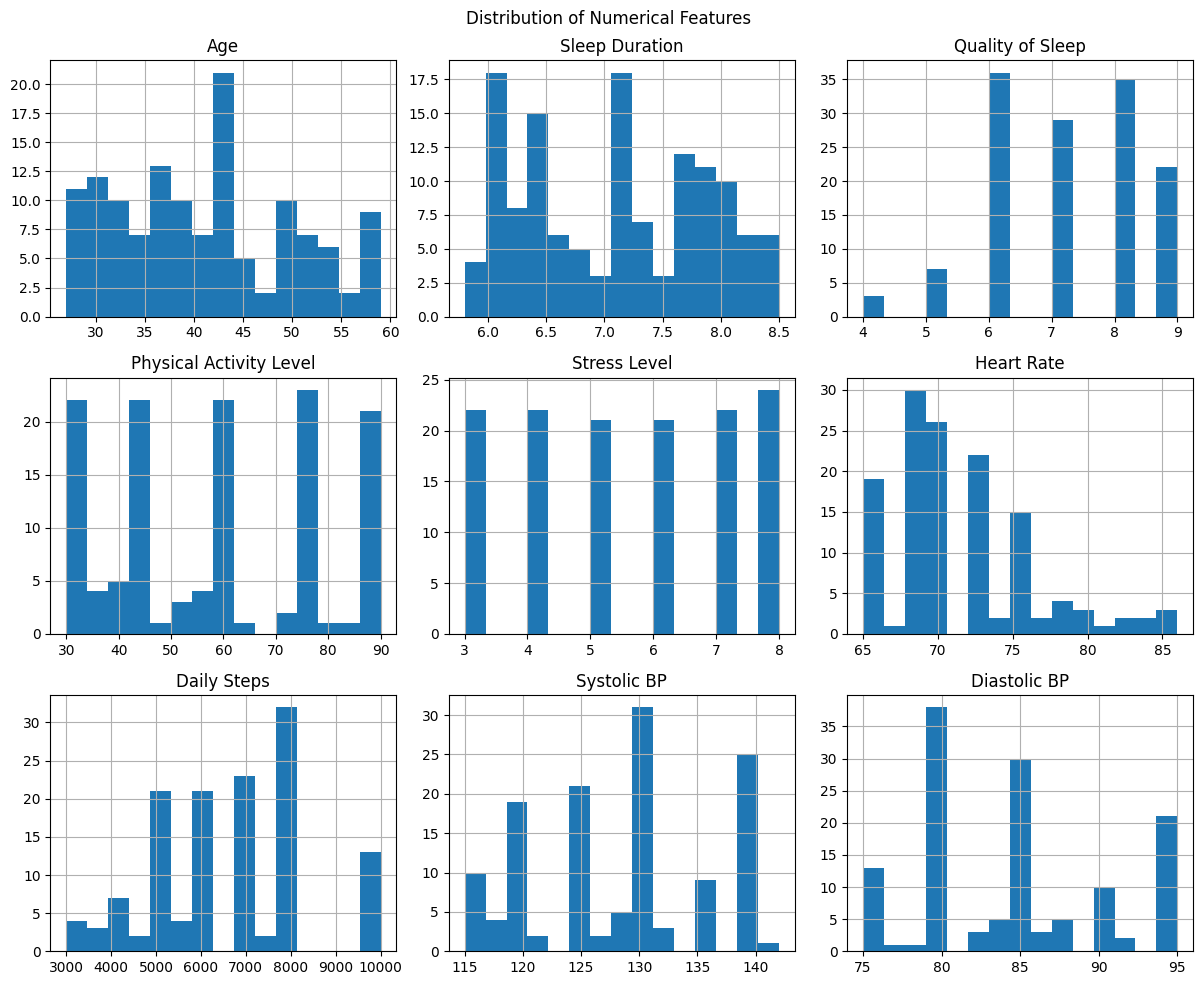

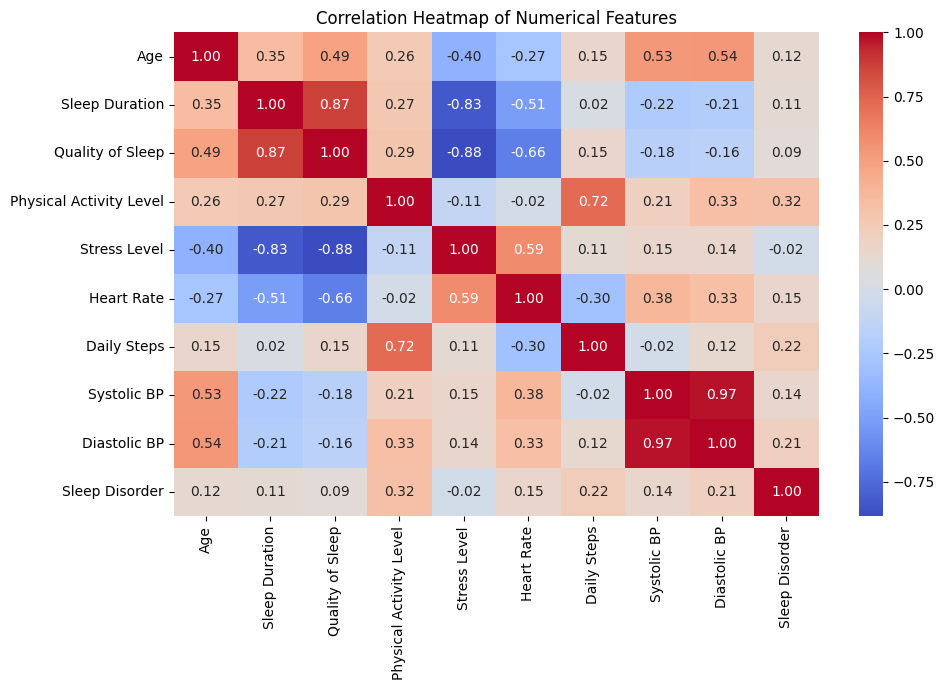

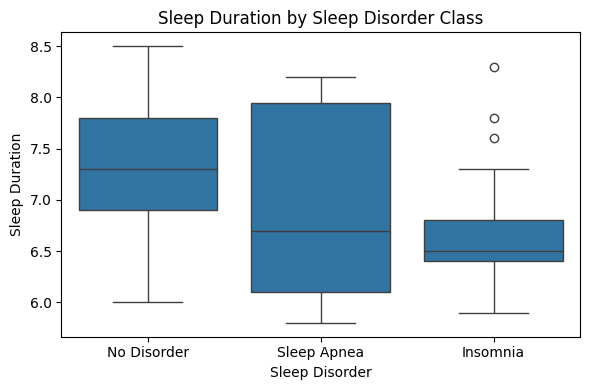

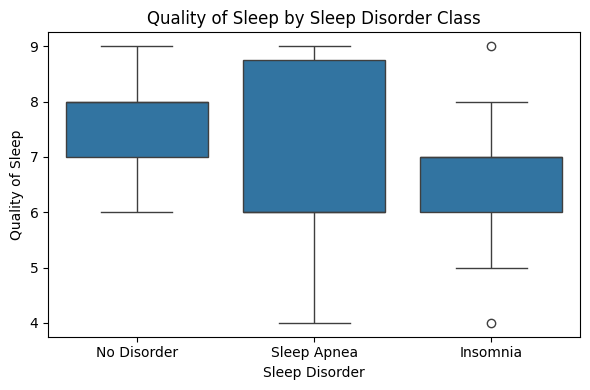

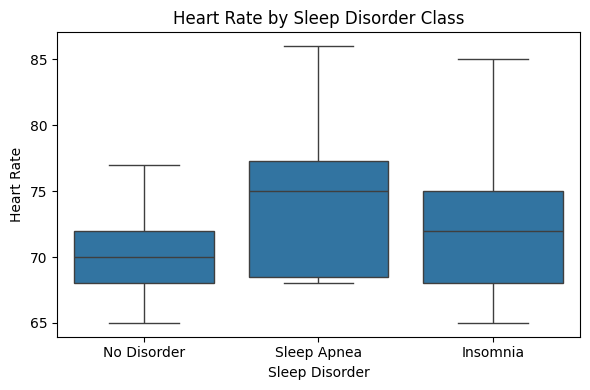

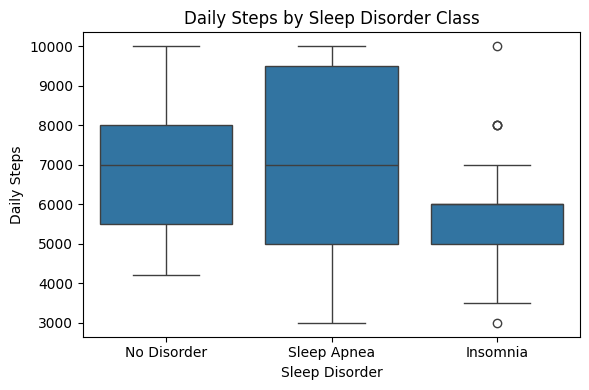

In [32]:
# Create a copy for EDA with readable class labels
eda_data = data.copy()
eda_data['Sleep Disorder Label'] = le_target.inverse_transform(eda_data['Sleep Disorder'])

# 1. Class distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=eda_data, x='Sleep Disorder Label')
plt.title('Distribution of Sleep Disorder Classes')
plt.xlabel('Sleep Disorder')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 2. Distribution of main numerical features
numeric_features = [
    'Age', 'Sleep Duration', 'Quality of Sleep',
    'Physical Activity Level', 'Stress Level',
    'Heart Rate', 'Daily Steps',
    'Systolic BP', 'Diastolic BP'
]

data[numeric_features].hist(figsize=(12, 10), bins=15)
plt.suptitle('Distribution of Numerical Features')
plt.tight_layout()
plt.show()

# 3. Correlation heatmap
corr_data = data[numeric_features + ['Sleep Disorder']].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_data, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

# 4. Boxplots for selected important features by class
selected_eda_features = ['Sleep Duration', 'Quality of Sleep', 'Heart Rate', 'Daily Steps']

for feature in selected_eda_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=eda_data, x='Sleep Disorder Label', y=feature)
    plt.title(f'{feature} by Sleep Disorder Class')
    plt.xlabel('Sleep Disorder')
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

## 7. Train/Test Split

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=10,
    stratify=y
)

print('Training set:', X_train.shape)
print('Testing set:', X_test.shape)
print('\nClass distribution in training set:')
print(y_train.value_counts())

Training set: (105, 21)
Testing set: (27, 21)

Class distribution in training set:
Sleep Disorder
1    58
2    24
0    23
Name: count, dtype: int64


## 8. Build and Tune ANN Model + Parameter Plotting

Fitting 5 folds for each of 40 candidates, totalling 200 fits


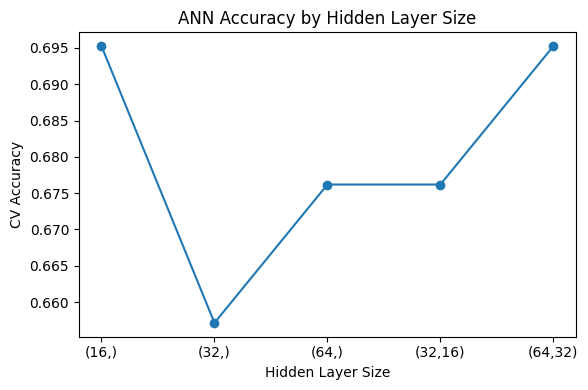

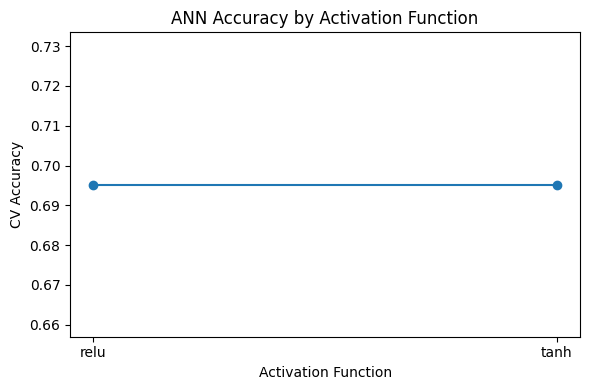

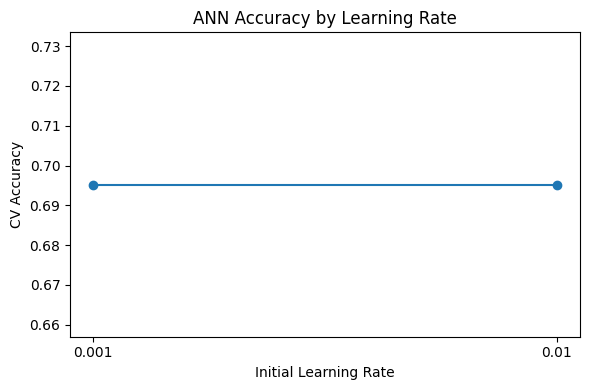

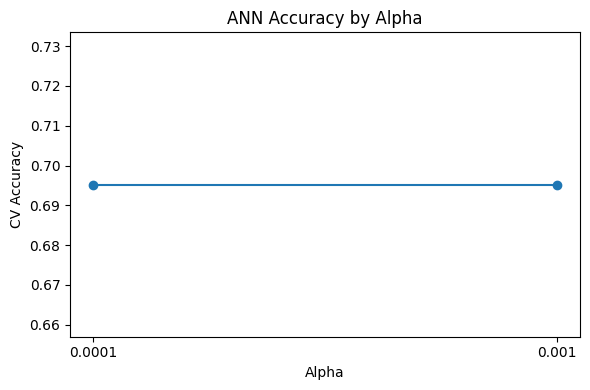


Best Parameters: {'ann__activation': 'relu', 'ann__alpha': 0.0001, 'ann__hidden_layer_sizes': (16,), 'ann__learning_rate_init': 0.01}
Best CV Accuracy: 0.6952


In [34]:
# Pipeline: scaling -> SMOTE -> ANN
# Scaling and SMOTE inside pipeline prevents data leakage across folds

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('ann', MLPClassifier(max_iter=2000, random_state=42, early_stopping=True))
])

param_grid = {
    'ann__hidden_layer_sizes': [(16,), (32,), (64,), (32, 16), (64, 32)],
    'ann__activation': ['relu', 'tanh'],
    'ann__learning_rate_init': [0.001, 0.01],
    'ann__alpha': [0.0001, 0.001]
}

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

ann_grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=kfold,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

ann_grid.fit(X_train, y_train)

results = pd.DataFrame(ann_grid.cv_results_)

#plot hidden layer size vs accuracy
hl_results = results.groupby('param_ann__hidden_layer_sizes')['mean_test_score'].max()
hl_labels = ['(16,)', '(32,)', '(64,)', '(32,16)', '(64,32)']
plt.figure(figsize=(6, 4))
plt.plot(hl_labels, hl_results.values, marker='o')
plt.xlabel('Hidden Layer Size')
plt.ylabel('CV Accuracy')
plt.title('ANN Accuracy by Hidden Layer Size')
plt.tight_layout()
plt.savefig('ann_hidden_layer_size.png')
plt.show()

#plot activation function vs accuracy
act_results = results.groupby('param_ann__activation')['mean_test_score'].max()
plt.figure(figsize=(6, 4))
plt.plot(act_results.index, act_results.values, marker='o')
plt.xlabel('Activation Function')
plt.ylabel('CV Accuracy')
plt.title('ANN Accuracy by Activation Function')
plt.tight_layout()
plt.savefig('ann_activation_function.png')
plt.show()

#plot accuracy vs learning rate
lr_results = results.groupby('param_ann__learning_rate_init')['mean_test_score'].max()
plt.figure(figsize=(6, 4))
plt.plot([str(x) for x in lr_results.index], lr_results.values, marker='o')
plt.xlabel('Initial Learning Rate')
plt.ylabel('CV Accuracy')
plt.title('ANN Accuracy by Learning Rate')
plt.tight_layout()
plt.savefig('ann_learning_rate.png')
plt.show()

#plot alpha vs accuracy
alpha_results = results.groupby('param_ann__alpha')['mean_test_score'].max()
plt.figure(figsize=(6, 4))
plt.plot([str(x) for x in alpha_results.index], alpha_results.values, marker='o')
plt.xlabel('Alpha')
plt.ylabel('CV Accuracy')
plt.title('ANN Accuracy by Alpha')
plt.tight_layout()
plt.savefig('ann_alpha.png')
plt.show()

print('\nBest Parameters:', ann_grid.best_params_)
print('Best CV Accuracy:', round(ann_grid.best_score_, 4))

## 9. Evaluate on Test Set

In [35]:
y_pred = ann_grid.predict(X_test)

ann_accuracy  = accuracy_score(y_test, y_pred)
ann_precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
ann_recall    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
ann_f1        = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print('ANN Test Results')
print('Accuracy: ', round(ann_accuracy, 4))
print('Precision:', round(ann_precision, 4))
print('Recall:   ', round(ann_recall, 4))
print('F1-score: ', round(ann_f1, 4))

ANN Test Results
Accuracy:  0.7037
Precision: 0.7048
Recall:    0.7037
F1-score:  0.7024


## 10. Classification Report

In [36]:
print(classification_report(
    y_test,
    y_pred,
    target_names=target_names,
    zero_division=0
))

              precision    recall  f1-score   support

    Insomnia       0.60      0.50      0.55         6
 No Disorder       0.80      0.80      0.80        15
 Sleep Apnea       0.57      0.67      0.62         6

    accuracy                           0.70        27
   macro avg       0.66      0.66      0.65        27
weighted avg       0.70      0.70      0.70        27



## 11. Confusion Matrix

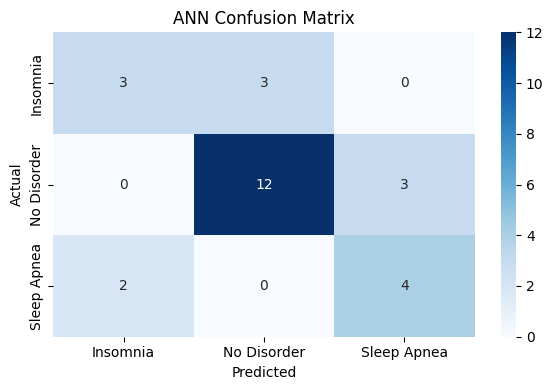

In [37]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('ANN Confusion Matrix')
plt.tight_layout()
plt.show()

## 12. Results Summary

In [38]:
ann_results = pd.DataFrame({
    'Model': ['ANN'],
    'CV Accuracy': [round(ann_grid.best_score_, 4)],
    'Test Accuracy': [round(ann_accuracy, 4)],
    'Precision': [round(ann_precision, 4)],
    'Recall': [round(ann_recall, 4)],
    'F1-score': [round(ann_f1, 4)]
})

ann_results

,Model,CV Accuracy,Test Accuracy,Precision,Recall,F1-score
0,ANN,0.6952,0.7037,0.7048,0.7037,0.7024


## 13. ANN Performance with Selected Features

In [40]:
# These feature lists were obtained from the SVM notebook after running RFECV and correlation-based feature selection.

selected_features = [
    'Sleep Duration', 'Quality of Sleep', 'Heart Rate', 'Daily Steps',
    'Systolic BP', 'Diastolic BP',
    'Occupation_Doctor', 'Occupation_Other'
]

best_v2_features = [
    'Diastolic BP', 'Systolic BP',
    'BMI Category_Normal', 'BMI Category_Overweight',
    'Heart Rate', 'Occupation_Nurse',
    'Quality of Sleep', 'Sleep Duration',
    'Occupation_Engineer', 'BMI Category_Obese'
]

def evaluate_ann_features(feature_list, feature_set_name):
    best_params = ann_grid.best_params_

    ann_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('ann', MLPClassifier(
            hidden_layer_sizes=best_params['ann__hidden_layer_sizes'],
            activation=best_params['ann__activation'],
            learning_rate_init=best_params['ann__learning_rate_init'],
            alpha=best_params['ann__alpha'],
            max_iter=2000,
            random_state=42,
            early_stopping=True
        ))
    ])

    ann_pipeline.fit(X_train[feature_list], y_train)
    pred = ann_pipeline.predict(X_test[feature_list])

    cv_scores = cross_val_score(
        ann_pipeline,
        X_train[feature_list],
        y_train,
        cv=kfold,
        scoring='accuracy'
    )

    return {
        'Feature Set': feature_set_name,
        'Model': 'ANN',
        'Number of Features': len(feature_list),
        'Accuracy': round(accuracy_score(y_test, pred), 4),
        'CV Average Accuracy': round(cv_scores.mean(), 6),
        'CV Standard Deviation': round(cv_scores.std(), 6),
        'Precision': round(precision_score(y_test, pred, average='weighted', zero_division=0), 4),
        'Recall': round(recall_score(y_test, pred, average='weighted', zero_division=0), 4),
        'F1-score': round(f1_score(y_test, pred, average='weighted', zero_division=0), 4)
    }

ann_feature_results = pd.DataFrame([
    evaluate_ann_features(X_train.columns.tolist(), 'All Features'),
    evaluate_ann_features(best_v2_features, 'Best V/2 Features'),
    evaluate_ann_features(selected_features, 'RFECV-selected Features')
])

ann_feature_results

,Feature Set,Model,Number of Features,Accuracy,CV Average Accuracy,CV Standard Deviation,Precision,Recall,F1-score
0,All Features,ANN,21,0.7037,0.695238,0.088320,0.7048,0.7037,0.7024
1,Best V/2 Features,ANN,10,0.7407,0.619048,0.173009,0.7365,0.7407,0.7366
2,RFECV-selected Features,ANN,8,0.7778,0.590476,0.077372,0.7768,0.7778,0.7702
